In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import warnings, sys
warnings.filterwarnings('ignore')
sys.path.append('../..')
from src.utils.config import PROCESSED_DIR, RAW_DIR
plt.style.use('seaborn-v0_8-darkgrid')
# Load AAPL and macro data
aapl = pd.read_csv(PROCESSED_DIR / 'features/AAPL_features.csv',
                   index_col=0, parse_dates=True)
macro = pd.read_csv(PROCESSED_DIR / 'features/macro_clean.csv',
                    index_col=0, parse_dates=True)
# Align dates
common_idx = aapl.index.intersection(macro.index)
aapl  = aapl.loc[common_idx]
macro = macro.loc[common_idx]

In [2]:
print(f'AAPL features: {aapl.shape}')
print(f'Macro features: {macro.shape}')
print(f'Aligned rows: {len(common_idx)}')

AAPL features: (2508, 47)
Macro features: (2508, 15)
Aligned rows: 2508


In [ ]:
def classify_regime(row):
    vix_high  = row['vix'] > 25
    price_above_sma200 = row['Price_vs_SMA200'] > 0
    if not vix_high and price_above_sma200:
        return 'Low Vol Bull'      # Best regime
    elif vix_high and price_above_sma200:
        return 'High Vol Bull'     # Risky
    elif not vix_high and not price_above_sma200:
        return 'Low Vol Bear'      # Grinding down
    else:
        return 'High Vol Bear'     # Worst regime — crash
# Merging macro VIX into AAPL data
combined = aapl.copy()
combined['vix'] = macro['vix']
combined = combined.dropna(subset=['vix', 'Price_vs_SMA200'])
# Classifying each day
combined['Regime'] = combined.apply(classify_regime, axis=1)
# Summary
regime_counts = combined['Regime'].value_counts()
print('Days in each regime:')
print(regime_counts)
print(f'\nPercentage breakdown:')
print((regime_counts / len(combined) * 100).round(1))

Days in each regime:
Regime
Low Vol Bull     1701
Low Vol Bear      446
High Vol Bull     214
High Vol Bear     147
Name: count, dtype: int64

Percentage breakdown:
Regime
Low Vol Bull     67.8
Low Vol Bear     17.8
High Vol Bull     8.5
High Vol Bear     5.9
Name: count, dtype: float64


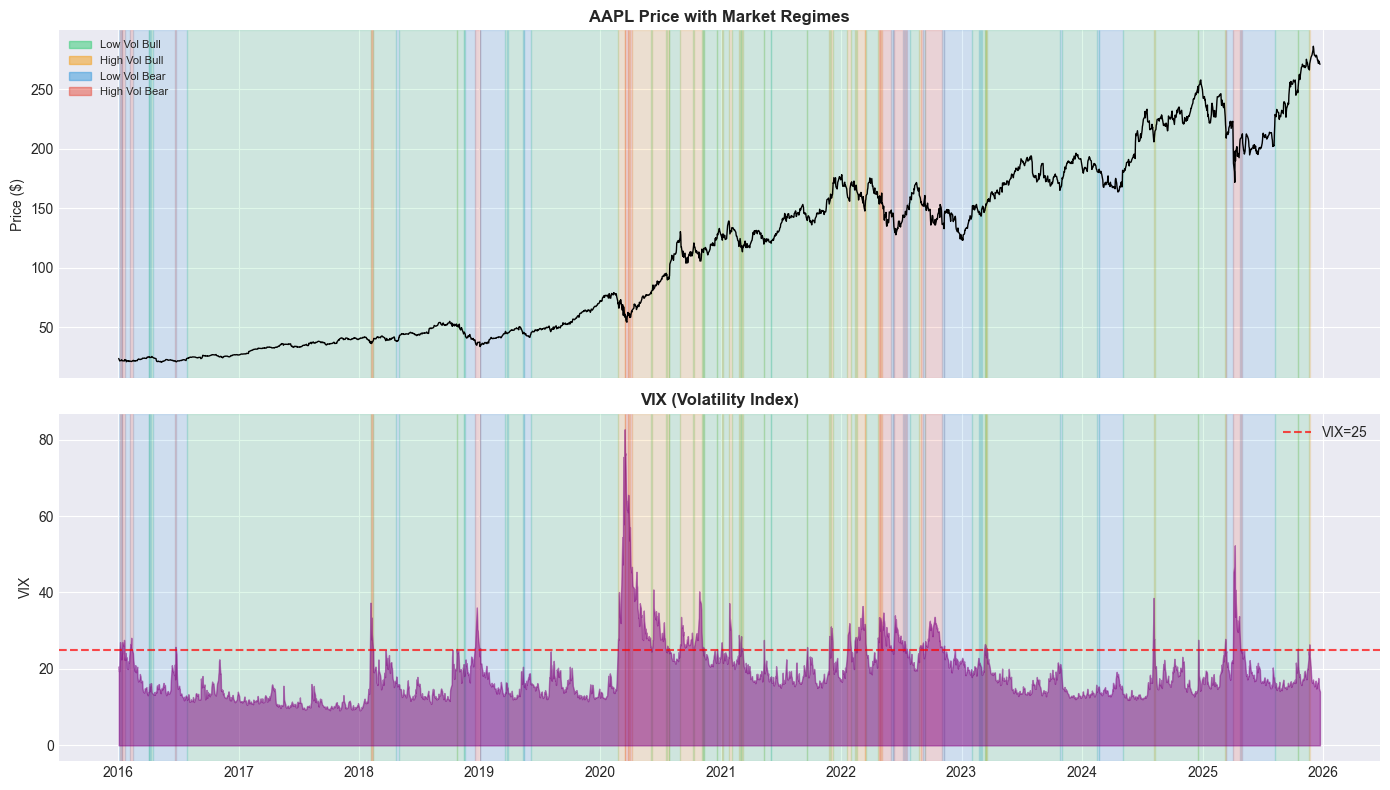

In [ ]:
REGIME_COLORS = {
    'Low Vol Bull':  '#2ECC71',   # Green
    'High Vol Bull': '#F39C12',   # Orange
    'Low Vol Bear':  '#3498DB',   # Blue
    'High Vol Bear': '#E74C3C',   # Red
}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Top: Price chart
ax1.plot(combined.index, combined['Close'], color='black',
         linewidth=1, label='AAPL Price')
ax1.set_ylabel('Price ($)')
ax1.set_title('AAPL Price with Market Regimes', fontweight='bold')

# Color background by regime
prev_regime = None
start_idx = combined.index[0]

for date, row in combined.iterrows():
    if row['Regime'] != prev_regime:
        if prev_regime is not None:
            for ax in [ax1, ax2]:
                ax.axvspan(start_idx, date,
                           alpha=0.15,
                           color=REGIME_COLORS[prev_regime])
        start_idx = date
        prev_regime = row['Regime']

# Bottom: VIX
ax2.fill_between(combined.index, combined['vix'],
                  color='purple', alpha=0.5)
ax2.axhline(25, color='red', linestyle='--', alpha=0.7, label='VIX=25')
ax2.set_ylabel('VIX')
ax2.set_title('VIX (Volatility Index)', fontweight='bold')
ax2.legend()

# Adding regime legend
patches = [mpatches.Patch(color=c, alpha=0.5, label=r)
           for r, c in REGIME_COLORS.items()]
ax1.legend(handles=patches, loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig('../../docs/eda/09_regime_timeline.png', dpi=150)
plt.show()

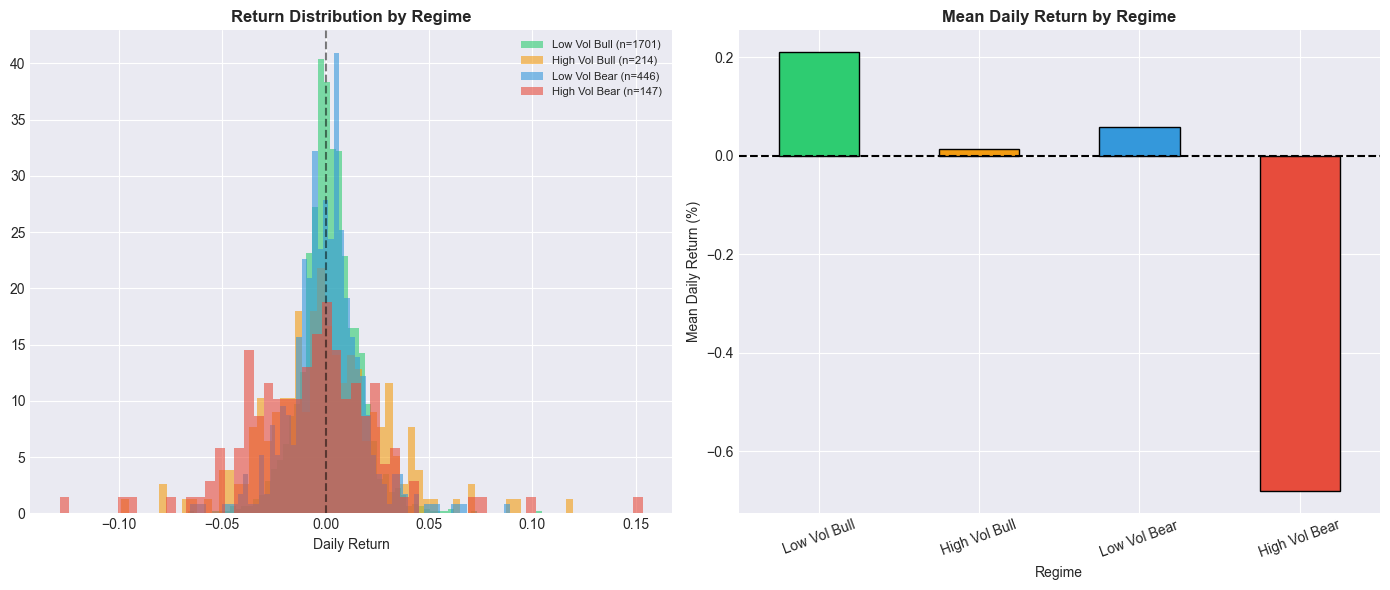


Regime Statistics:
               Mean Return (%)  Win Rate (%)  Sharpe
Regime                                              
Low Vol Bull             0.210        55.497   2.354
High Vol Bull            0.013        48.131   0.072
Low Vol Bear             0.058        53.139   0.520
High Vol Bear           -0.682        42.177  -3.213


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Return distribution by regime
for regime, color in REGIME_COLORS.items():
    regime_data = combined[combined['Regime'] == regime]['Daily_Return'].dropna()
    axes[0].hist(regime_data, bins=60, alpha=0.6,
                 label=f'{regime} (n={len(regime_data)})',
                 color=color, density=True)

axes[0].set_title('Return Distribution by Regime', fontweight='bold')
axes[0].set_xlabel('Daily Return')
axes[0].legend(fontsize=8)
axes[0].axvline(0, color='black', linestyle='--', alpha=0.5)

# Right: Mean return and win rate by regime
regime_stats = []
for regime in REGIME_COLORS:
    r_data = combined[combined['Regime'] == regime]['Daily_Return'].dropna()
    regime_stats.append({
        'Regime': regime,
        'Mean Return (%)': r_data.mean() * 100,
        'Win Rate (%)': (r_data > 0).mean() * 100,
        'Sharpe': r_data.mean() / r_data.std() * np.sqrt(252)
    })

regime_stats_df = pd.DataFrame(regime_stats).set_index('Regime')
regime_stats_df['Mean Return (%)'].plot(
    kind='bar', ax=axes[1],
    color=[REGIME_COLORS[r] for r in regime_stats_df.index],
    edgecolor='black'
)

axes[1].set_title('Mean Daily Return by Regime', fontweight='bold')
axes[1].set_ylabel('Mean Daily Return (%)')
axes[1].axhline(0, color='black', linestyle='--')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('../../docs/eda/10_returns_by_regime.png', dpi=150)
plt.show()

print('\nRegime Statistics:')
print(regime_stats_df.round(3))

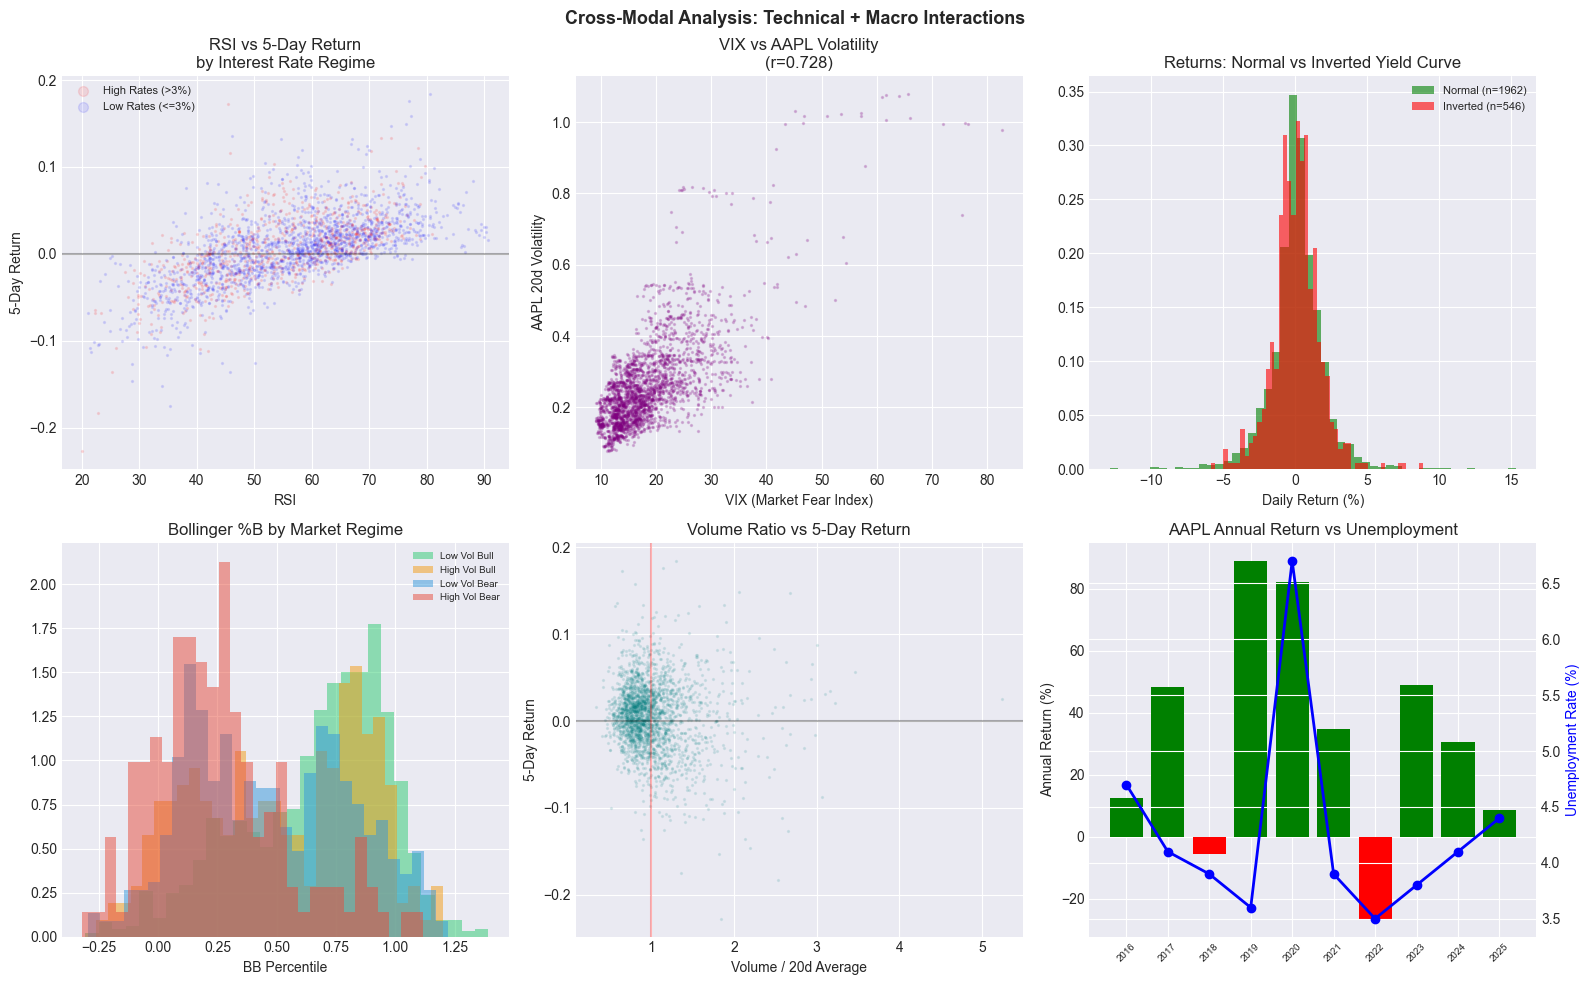

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Analysis 1: RSI vs Returns in different rate environments
rate_high = combined[macro['fed_funds_rate'] > 3]
rate_low  = combined[macro['fed_funds_rate'] <= 3]

axes[0,0].scatter(rate_high['RSI_14'],
                   rate_high['Return_5d'],
                   alpha=0.1, color='red', s=2, label='High Rates (>3%)')
axes[0,0].scatter(rate_low['RSI_14'],
                   rate_low['Return_5d'],
                   alpha=0.1, color='blue', s=2, label='Low Rates (<=3%)')
axes[0,0].set_title('RSI vs 5-Day Return\nby Interest Rate Regime')
axes[0,0].set_xlabel('RSI')
axes[0,0].set_ylabel('5-Day Return')
axes[0,0].axhline(0, color='black', alpha=0.3)
axes[0,0].legend(markerscale=5, fontsize=8)

# Analysis 2: Volatility vs Macro VIX
axes[0,1].scatter(combined['vix'],
                   combined['Volatility_20d'],
                   alpha=0.2, color='purple', s=2)
axes[0,1].set_title('VIX vs AAPL 20d Volatility\n(Should be correlated)')
axes[0,1].set_xlabel('VIX (Market Fear Index)')
axes[0,1].set_ylabel('AAPL 20d Volatility')
corr_val = combined['vix'].corr(combined['Volatility_20d'])
axes[0,1].set_title(
    f'VIX vs AAPL Volatility\n(r={corr_val:.3f})')

# Analysis 3: Yield curve vs returns
inverted = combined[macro['yield_curve'] < 0]
normal   = combined[macro['yield_curve'] >= 0]

axes[0,2].hist(normal['Daily_Return'].dropna() * 100,
               bins=50, alpha=0.6, color='green',
               label=f'Normal (n={len(normal)})', density=True)
axes[0,2].hist(inverted['Daily_Return'].dropna() * 100,
               bins=50, alpha=0.6, color='red',
               label=f'Inverted (n={len(inverted)})', density=True)
axes[0,2].set_title('Returns: Normal vs Inverted Yield Curve')
axes[0,2].set_xlabel('Daily Return (%)')
axes[0,2].legend(fontsize=8)

# Analysis 4: BB_Pct distribution by regime
for regime, color in REGIME_COLORS.items():
    r_data = combined[combined['Regime'] == regime]['BB_Pct'].dropna()
    axes[1,0].hist(r_data, bins=30, alpha=0.5,
                   label=regime, color=color, density=True)
axes[1,0].set_title('Bollinger %B by Market Regime')
axes[1,0].set_xlabel('BB Percentile')
axes[1,0].legend(fontsize=7)

# Analysis 5: Volume ratio vs forward returns
axes[1,1].scatter(combined['Volume_Ratio'],
                   combined['Return_5d'],
                   alpha=0.1, color='teal', s=2)
axes[1,1].set_title('Volume Ratio vs 5-Day Return')
axes[1,1].set_xlabel('Volume / 20d Average')
axes[1,1].set_ylabel('5-Day Return')
axes[1,1].axhline(0, color='black', alpha=0.3)
axes[1,1].axvline(1, color='red', alpha=0.3)

# Analysis 6: Unemployment vs AAPL annual return
annual_ret = combined['Daily_Return'].resample('Y').apply(
    lambda x: (1 + x).prod() - 1) * 100
annual_unemp = macro['unemployment'].resample('Y').last()
common = annual_ret.index.intersection(annual_unemp.index)

axes[1,2].bar(range(len(common)),
              annual_ret.loc[common].values,
              color=['green' if r > 0 else 'red'
                     for r in annual_ret.loc[common].values])

ax2_twin = axes[1,2].twinx()
ax2_twin.plot(range(len(common)),
              annual_unemp.loc[common].values,
              color='blue', marker='o', linewidth=2)

axes[1,2].set_xticks(range(len(common)))
axes[1,2].set_xticklabels(
    [str(d.year) for d in common], rotation=45, fontsize=7)
axes[1,2].set_title('AAPL Annual Return vs Unemployment')
axes[1,2].set_ylabel('Annual Return (%)')
ax2_twin.set_ylabel('Unemployment Rate (%)', color='blue')

plt.suptitle('Cross-Modal Analysis: Technical + Macro Interactions',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../../docs/eda/11_cross_modal_analysis.png', dpi=150)
plt.show()